# DSAI LAB 8 Proshita Agarwal

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

STEP 1:

In [3]:
df = pd.read_csv("used_cars_dataset.csv")

# cleaning mileage
df["milage"] = df["milage"].str.replace(r"\D", "", regex=True)
df["milage"] = pd.to_numeric(df["milage"], errors="coerce")

# cleaning price
df["price"] = df["price"].str.replace(r"\D", "", regex=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Handling missing values
df = df.dropna(subset=["price", "milage"])   # drop rows missing key numeric values

for col in ["fuel_type", "accident"]:
    df[col] = df[col].fillna(df[col].mode()[0])   # fill missing with most common value

# One-Hot Encoding 
categorical_columns = ["brand", "fuel_type", "accident"]
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True, dtype=int)

print(df_encoded.head())

   model_year  milage  price  brand_Alfa  brand_Aston  brand_Audi  brand_BMW  \
0        2013   51000  10300           0            0           0          0   
1        2021   34742  38005           0            0           0          0   
2        2022   22372  54598           0            0           0          0   
3        2015   88900  15500           0            0           0          0   
4        2021    9835  34999           0            0           1          0   

   brand_Bentley  brand_Bugatti  brand_Buick  ...  brand_Volkswagen  \
0              0              0            0  ...                 0   
1              0              0            0  ...                 0   
2              0              0            0  ...                 0   
3              0              0            0  ...                 0   
4              0              0            0  ...                 0   

   brand_Volvo  brand_smart  fuel_type_E85 Flex Fuel  fuel_type_Gasoline  \
0            0  

STEP 2:

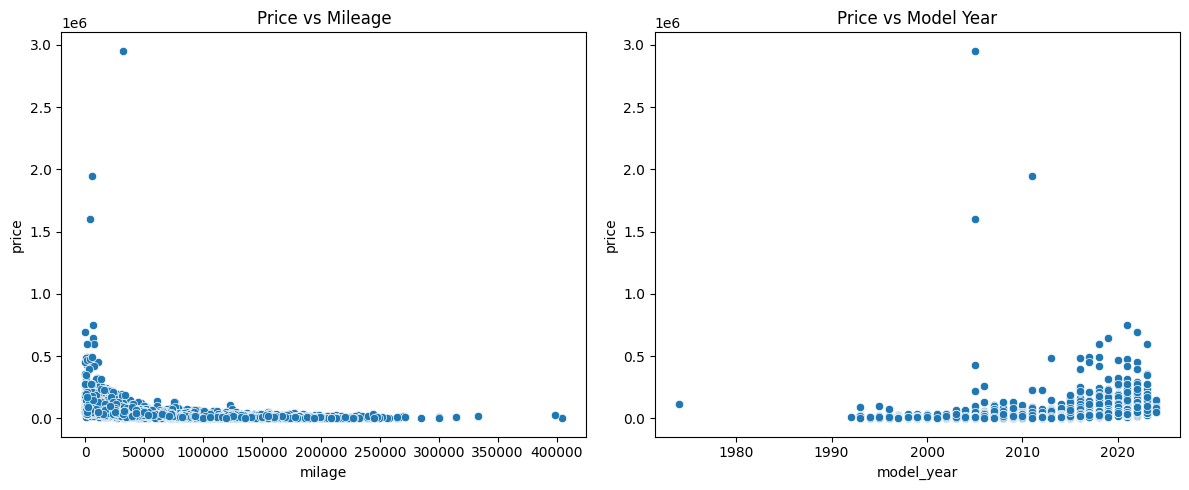

In [5]:
# Step 2: Data Visualization

import seaborn as sns

# Scatter plots: Price vs numerical features
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=df_encoded["milage"], y=df_encoded["price"])
plt.title("Price vs Mileage")

plt.subplot(1,2,2)
sns.scatterplot(x=df_encoded["model_year"], y=df_encoded["price"])
plt.title("Price vs Model Year")

plt.tight_layout()
plt.show()

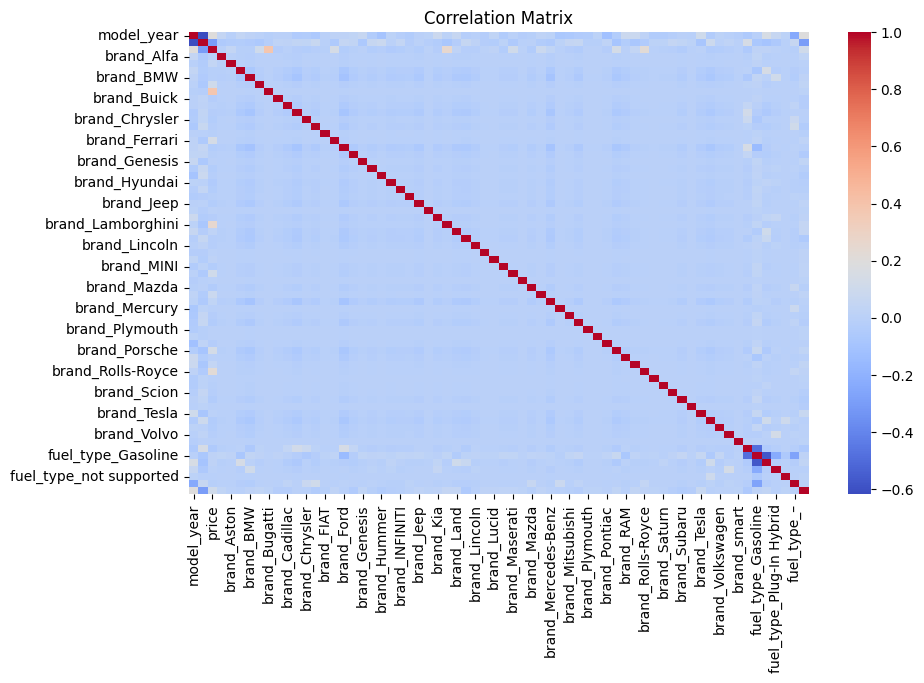

In [8]:
# Correlation matrix (numerical features only) 
plt.figure(figsize=(10,6))
corr = df_encoded.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

STEP 3:

In [6]:
# Step 3: Building the Multiple Linear Regression Model

from sklearn.linear_model import LinearRegression

# Defining features (X) and target (y)
X = df_encoded.drop("price", axis=1)   # independent variables
y = df_encoded["price"]                # target variable

# Fittinh the model
mlr = LinearRegression()
mlr.fit(X, y)

# Output coefficients and intercept
print("Intercept:", mlr.intercept_)
print("\nCoefficients:")

# Match coefficients with their feature names
for feature, coef in zip(X.columns, mlr.coef_):
    print(f"{feature}: {coef}")

Intercept: -2229513.6964930333

Coefficients:
model_year: 1138.0520217292014
milage: -0.264590497794461
brand_Alfa: -8347.758512991437
brand_Aston: 73781.68445149506
brand_Audi: 4967.204078328941
brand_BMW: 7650.915733850365
brand_Bentley: 96707.45678818609
brand_Bugatti: 1909230.392909839
brand_Buick: -6721.964125933009
brand_Cadillac: 11821.839162910597
brand_Chevrolet: 8016.8530855175195
brand_Chrysler: -10316.517159305295
brand_Dodge: 10688.572580410328
brand_FIAT: -19477.88569267289
brand_Ferrari: 197256.82173195606
brand_Ford: 4812.171193214483
brand_GMC: 7340.390076967888
brand_Genesis: -6615.5935574150935
brand_Honda: -296.8213559371943
brand_Hummer: 17792.59534453071
brand_Hyundai: -12364.215229983878
brand_INFINITI: -2507.821399702152
brand_Jaguar: -638.7850136733177
brand_Jeep: 434.63489458948607
brand_Karma: 7368.820500643895
brand_Kia: -11650.327316050505
brand_Lamborghini: 245346.62297944014
brand_Land: 19588.741411761774
brand_Lexus: 8578.437111967534
brand_Lincoln: -326

STEP 4:

In [7]:
# Step 4: Model Evaluation

from sklearn.metrics import r2_score
import statsmodels.api as sm

# R² (with sklearn model)
y_pred = mlr.predict(X)
r2 = r2_score(y, y_pred)
print("R²:", r2)

# Adjusted R²
n = X.shape[0]   # number of observations
p = X.shape[1]   # number of predictors
adj_r2 = 1 - (1-r2) * (n-1)/(n-p-1)
print("Adjusted R²:", adj_r2)

# F-test with OLS (Ordinary Least Squares)
X_with_const = sm.add_constant(X)   # add intercept manually
ols_model = sm.OLS(y, X_with_const).fit()
print("\nOLS Regression Summary:")
print(ols_model.summary())

R²: 0.4061739501774715
Adjusted R²: 0.3963847812100699

OLS Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     41.49
Date:                Thu, 02 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:25:42   Log-Likelihood:                -49839.
No. Observations:                4009   AIC:                         9.981e+04
Df Residuals:                    3943   BIC:                         1.002e+05
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

### REPORT:

In this lab, I applied multiple linear regression to a used cars dataset. The process began with data cleaning, where I converted mileage and price into numeric form, handled missing values, and used one-hot encoding for categorical features. I then visualized the data with scatter plots and a correlation heatmap to identify key trends and check for multicollinearity. The regression model was built using scikit-learn’s LinearRegression, and I evaluated it with R², adjusted R², and an F-test through statsmodels. This combination of cleaning, visualization, modeling, and statistical evaluation gave me a clear understanding of how regression methods can be applied to real-world data.